In [1]:
# 1. Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Settings
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

In [3]:
# 2. Load Dataset
# ===============================
df = pd.read_csv(r"/content/netflix_titles.csv")

In [4]:
# Preview
print(df.head())
print(df.info())


  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24, 2021        

# Data Cleaning

In [5]:
# Remove duplicates
df.drop_duplicates(inplace=True)

In [6]:
# Handle missing values
df['director'].fillna('Unknown', inplace=True)
df['cast'].fillna('Not Available', inplace=True)
df['country'].fillna('Unknown', inplace=True)
df['rating'].fillna(df['rating'].mode()[0], inplace=True)

/tmp/ipykernel_1858/3356393054.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['director'].fillna('Unknown', inplace=True)
/tmp/ipykernel_1858/3356393054.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

In [7]:
# Convert date column
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

In [8]:
# Extract year added
df['year_added'] = df['date_added'].dt.year

#Exploratory Data Analysis

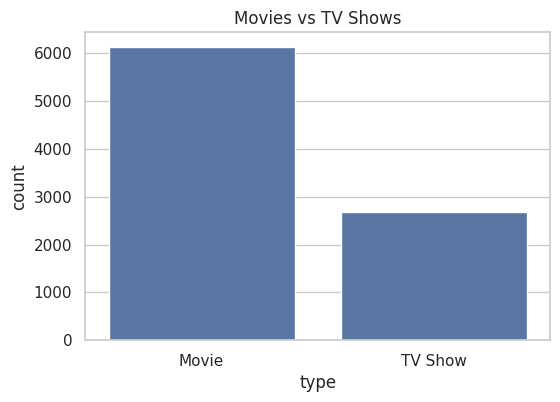

In [12]:
# Movies vs TV Shows
type_counts = df['type'].value_counts()

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='type')
plt.title("Movies vs TV Shows")
plt.show()

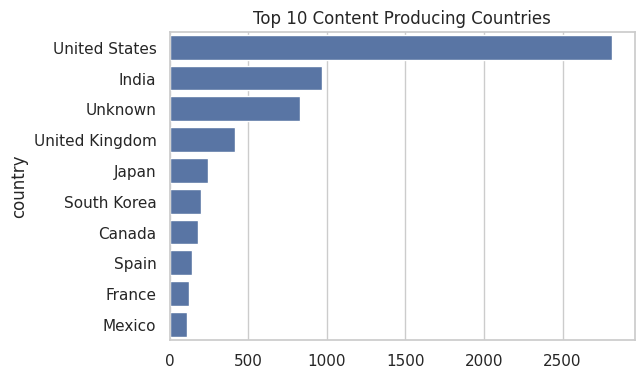

In [11]:
# Top 10 countries
top_countries = df['country'].value_counts().head(10)

plt.figure(figsize=(6,4))
sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title("Top 10 Content Producing Countries")
plt.show()

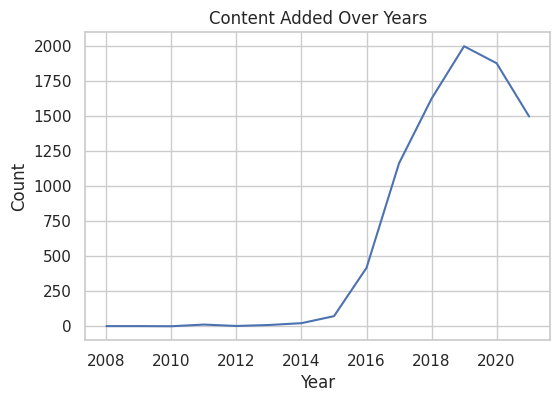

In [14]:
#Content added over years
year_data = df['year_added'].value_counts().sort_index()

plt.figure(figsize=(6,4))
sns.lineplot(x=year_data.index, y=year_data.values)
plt.title("Content Added Over Years")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

#Genre Analysis

In [15]:
# Split genres
df['listed_in'] = df['listed_in'].str.split(',')

In [16]:
# Explode genres
genre_df = df.explode('listed_in')

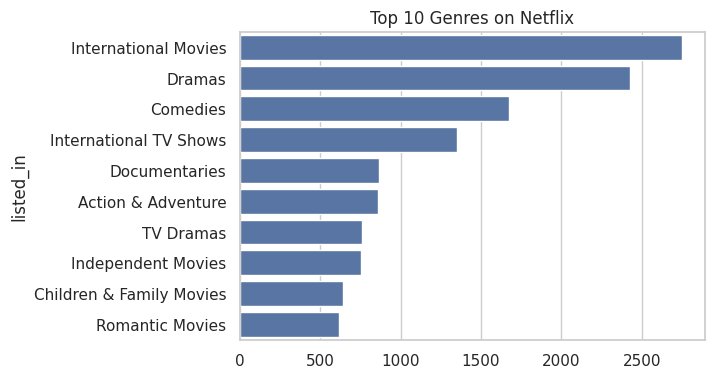

In [17]:
# Clean spaces
genre_df['listed_in'] = genre_df['listed_in'].str.strip()

top_genres = genre_df['listed_in'].value_counts().head(10)

plt.figure(figsize=(6,4))
sns.barplot(x=top_genres.values, y=top_genres.index)
plt.title("Top 10 Genres on Netflix")
plt.show()

#Correlation Heatmap

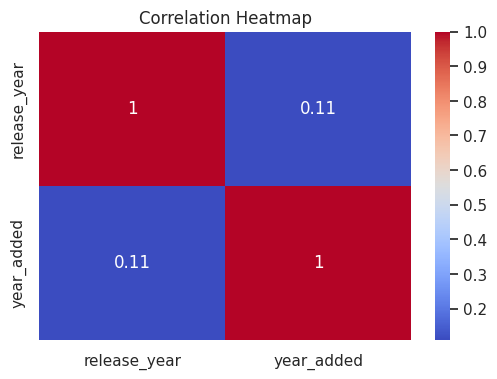

In [19]:
numeric_df = df.select_dtypes(include=[np.number])

if not numeric_df.empty:
    plt.figure(figsize=(6,4))
    sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
    plt.title("Correlation Heatmap")
    plt.show()

#Save Cleaned Dataset

In [21]:
df.to_csv("cleaned_netflix_data.csv", index=False)

print("Project Completed Successfully!")

Project Completed Successfully!
